In [10]:
import os
import csv
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

There are spaces in class names in the data. 
- Replace the spaces with underscore 

In [11]:
os.listdir("../")

['.gitignore', '.ipynb_checkpoints', 'data', 'experiments', 'readme.md']

In [12]:
os.listdir("../data/")

['EfficientNetB0-100-(224 X 224)- 98.40.h5',
 'sports.csv',
 'test',
 'train',
 'valid']

In [13]:
# Print 5 lines from the `sports.csv`
filename = '../data/sports.csv'
lines_to_print = 5
with open(filename, mode='r', newline='') as csvfile:
    csv_reader = csv.reader(csvfile)
    for index, row in enumerate(csv_reader):
        if index >= lines_to_print:
            break
        print(row)


['class id', 'filepaths', 'labels', 'data set']
['0', 'train/air hockey/001.jpg', 'air hockey', 'train']
['0', 'train/air hockey/002.jpg', 'air hockey', 'train']
['0', 'train/air hockey/003.jpg', 'air hockey', 'train']
['0', 'train/air hockey/004.jpg', 'air hockey', 'train']


In [14]:
# First replace spaces with underscores from this sports.csv file:
# Read all rows first
with open(filename, mode='r', newline='') as file:
    reader = csv.reader(file)
    rows = [[col.replace(' ', '_') for col in row] for row in reader]
# Write back to the same file
with open(filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(rows)

In [15]:
# Let's verify..
# Print 5 lines from the `sports.csv`
filename = '../data/sports.csv'
lines_to_print = 5
with open(filename, mode='r', newline='') as csvfile:
    csv_reader = csv.reader(csvfile)
    for index, row in enumerate(csv_reader):
        if index >= lines_to_print:
            break
        print(row)

['class_id', 'filepaths', 'labels', 'data_set']
['0', 'train/air_hockey/001.jpg', 'air_hockey', 'train']
['0', 'train/air_hockey/002.jpg', 'air_hockey', 'train']
['0', 'train/air_hockey/003.jpg', 'air_hockey', 'train']
['0', 'train/air_hockey/004.jpg', 'air_hockey', 'train']


In [18]:
# Now, let's replace the whitespaces in the directory names to underscore 
parent_folder = '../data/test/'
for name in os.listdir(parent_folder):
    old_path = os.path.join(parent_folder, name)
    # Check if it's a directory
    if os.path.isdir(old_path):
        new_name = name.replace(' ', '_')
        # new_name = name.replace('_', '')
        new_path = os.path.join(parent_folder, new_name)
        # Rename only if needed
        if old_path != new_path:
            os.rename(old_path, new_path)
            print(f"Renamed: {name} → {new_name}")

Renamed: air hockey → air_hockey
Renamed: ampute football → ampute_football
Renamed: arm wrestling → arm_wrestling
Renamed: axe throwing → axe_throwing
Renamed: balance beam → balance_beam
Renamed: barell racing → barell_racing
Renamed: baton twirling → baton_twirling
Renamed: bike polo → bike_polo
Renamed: bull riding → bull_riding
Renamed: bungee jumping → bungee_jumping
Renamed: canoe slamon → canoe_slamon
Renamed: chuckwagon racing → chuckwagon_racing
Renamed: disc golf → disc_golf
Renamed: field hockey → field_hockey
Renamed: figure skating men → figure_skating_men
Renamed: figure skating pairs → figure_skating_pairs
Renamed: figure skating women → figure_skating_women
Renamed: fly fishing → fly_fishing
Renamed: formula 1 racing → formula_1_racing
Renamed: giant slalom → giant_slalom
Renamed: hammer throw → hammer_throw
Renamed: hang gliding → hang_gliding
Renamed: harness racing → harness_racing
Renamed: high jump → high_jump
Renamed: horse jumping → horse_jumping
Renamed: horse 

In [17]:
# Previous one worked well.. here for the other two folders:
parent_folders = ['../data/train/', '../data/valid/']
for parent_folder in parent_folders:
    for name in os.listdir(parent_folder):
        old_path = os.path.join(parent_folder, name)
        # Check if it's a directory
        if os.path.isdir(old_path):
            new_name = name.replace(' ', '_')
            new_path = os.path.join(parent_folder, new_name)
            # Rename only if needed
            if old_path != new_path:
                os.rename(old_path, new_path)
                print(f"Renamed: {name} → {new_name}")

Renamed: air hockey → air_hockey
Renamed: ampute football → ampute_football
Renamed: arm wrestling → arm_wrestling
Renamed: axe throwing → axe_throwing
Renamed: balance beam → balance_beam
Renamed: barell racing → barell_racing
Renamed: baton twirling → baton_twirling
Renamed: bike polo → bike_polo
Renamed: bull riding → bull_riding
Renamed: bungee jumping → bungee_jumping
Renamed: canoe slamon → canoe_slamon
Renamed: chuckwagon racing → chuckwagon_racing
Renamed: disc golf → disc_golf
Renamed: field hockey → field_hockey
Renamed: figure skating men → figure_skating_men
Renamed: figure skating pairs → figure_skating_pairs
Renamed: figure skating women → figure_skating_women
Renamed: fly fishing → fly_fishing
Renamed: formula 1 racing → formula_1_racing
Renamed: giant slalom → giant_slalom
Renamed: hammer throw → hammer_throw
Renamed: hang gliding → hang_gliding
Renamed: harness racing → harness_racing
Renamed: high jump → high_jump
Renamed: horse jumping → horse_jumping
Renamed: horse 

**Now load 5 images from 5 different classes of train set, and show/plot, also check dimensions**

Class: air_hockey
Image: 059.jpg
Type: RGB, Shape: (224, 224, 3)
----------------------------------------
Class: horse_jumping
Image: 059.jpg
Type: RGB, Shape: (224, 224, 3)
----------------------------------------
Class: barell_racing
Image: 043.jpg
Type: RGB, Shape: (224, 224, 3)
----------------------------------------
Class: motorcycle_racing
Image: 051.jpg
Type: RGB, Shape: (224, 224, 3)
----------------------------------------
Class: water_cycling
Image: 034.jpg
Type: RGB, Shape: (224, 224, 3)
----------------------------------------


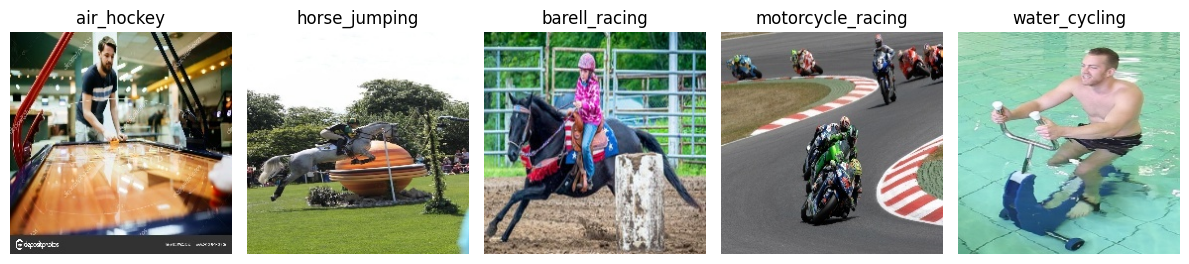

In [20]:
parent_folder = '../data/train'
images = []
selected_classes = ['air_hockey', 'horse_jumping', 'barell_racing', 'motorcycle_racing', 'water_cycling']
for cls in selected_classes:
    class_path = os.path.join(parent_folder, cls)
    # Get all image files in the class folder
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not files:
        print(f"No images found in {cls}")
        continue
    # Pick one random image
    img_file = random.choice(files)
    img_path = os.path.join(class_path, img_file)
    # Open image
    img = Image.open(img_path)
    img_array = np.array(img)
    # Determine type
    if len(img_array.shape) == 2:
        img_type = 'Grayscale (B/W)'
    elif len(img_array.shape) == 3:
        img_type = 'RGB'
    else:
        img_type = 'Unknown'
    print(f"Class: {cls}")
    print(f"Image: {img_file}")
    print(f"Type: {img_type}, Shape: {img_array.shape}")
    print('-' * 40)
    images.append((cls, img_array))

# Plot images
plt.figure(figsize=(12, 6))
for i, (cls, img) in enumerate(images):
    plt.subplot(1, 5, i + 1)
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [21]:
# How many classes?
parent_folders = ['../data/train/', '../data/valid/', '../data/test/']
for parent_folder in parent_folders:
    foldername = list(parent_folder.strip('/').split("/"))[-1]
    print(f"In {foldername} there are: {len(os.listdir(parent_folder))} classes.")

In train there are: 100 classes.
In valid there are: 100 classes.
In test there are: 100 classes.


In [22]:
# How many samples in train test valid?
parent_folders = ['../data/train/', '../data/valid/', '../data/test/']
for parent_folder in parent_folders:
    foldername = parent_folder.strip('/').split('/')[-1]
    total_images = 0
    # Loop through each class folder
    for class_name in os.listdir(parent_folder):
        class_path = os.path.join(parent_folder, class_name)
        if os.path.isdir(class_path):
            # Count image files
            images = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            total_images += len(images)
    print(f"In {foldername}: {total_images} images")

In train: 13492 images
In valid: 500 images
In test: 500 images
